# 🍷 Wine Quality Prediction - Progetto Capstone

## Contesto del Progetto

### Il Cliente: Cantina di Pregio Portoghese

La nostra cantina cliente, produttrice di **Vinho Verde** (vini verdi portoghesi), si trova di fronte a una sfida cruciale nel processo di produzione: **quale lotti di vino destinare all'affinamento in barrique** per ottenere vini di alta qualità destinati al mercato premium.

### La Richiesta dell'Enologo

L'enologo capo della cantina ci ha contattato con una richiesta specifica:

> *"Ogni anno produciamo centinaia di lotti di vino. Attualmente, la decisione su quali lotti far invecchiare nelle costose botti di rovere si basa principalmente sull'esperienza e sull'assaggio. Questo processo è:*
> - *Soggettivo e dipendente dalla disponibilità dell'enologo*
> - *Costoso in termini di tempo (richiede settimane per le valutazioni)*
> - *Rischioso: investiamo in barrique costose senza certezza del risultato finale*
>
> *Abbiamo bisogno di un sistema che, analizzando i parametri chimico-fisici del vino in fase iniziale, predica con affidabilità se un lotto merita l'investimento per l'affinamento premium."*

### Raccolta Dati

La cantina ha messo a disposizione il proprio **database storico** contenente:
- **Analisi chimico-fisiche** di oltre 6,000 campioni di vino
- **Valutazioni sensoriali** da parte di panel di esperti sommelier (score 0-10)
- Parametri misurati in laboratorio: acidità, pH, solfiti, alcol, residui zuccherini, ecc.

I dati provengono da:
1. **Laboratorio interno** della cantina (misure oggettive)
2. **Panel di degustazione certificato** (valutazione qualità)
3. **Archivio storico** delle decisioni di affinamento e risultati commerciali

### Dataset: UCI Wine Quality

Per questo progetto utilizziamo il dataset pubblico **UCI Wine Quality** (ID: 186), che rappresenta esattamente lo scenario descritto:
- **6,497 campioni** di vini Vinho Verde (rossi e bianchi)
- **11 variabili chimico-fisiche** misurate in laboratorio
- **Valutazione qualitativa** (0-10) da esperti enologi

### Obiettivo del Progetto

Sviluppare un **sistema di Machine Learning** che:
1. Predica la **probabilità che un vino sia di alta qualità** (score ≥ 7)
2. Supporta l'enologo nelle **decisioni di affinamento** 

### Deliverable

1. **Modello ML** addestrato e validato (pipeline scikit-learn)
2. **Webapp Streamlit** per l'utilizzo in cantina
3. **Sistema MLflow** per tracking e versionamento
4. **Explainability** (SHAP, Feature Importance) per trasparenza decisionale

---

## Esplorazione Dataset e Sviluppo Modello

## Come vedere l'addestramento dei modelli con MLflow

1. Esegui prima le celle di training del notebook: le run e le metriche vengono salvate nella cartella `capstone_project/mlruns`.
2. Apri un **terminale** nella cartella `capstone_project` e avvia l'interfaccia (non eseguire il comando in una cella del notebook):

   ```bash
   MLFLOW_ALLOW_FILE_STORE=true uv run mlflow ui --backend-store-uri file:mlruns --host 0.0.0.0 --port 5000
   ```

3. Apri [http://localhost:5000](http://localhost:5000). In Codespaces o in un ambiente remoto, apri la scheda **Ports**, inoltra la porta `5000` e visita l'URL fornito.
4. Seleziona l'esperimento **Wine Quality - Classificazione**. La tabella **Runs** mostra le esecuzioni; aprine una per vedere parametri, metriche (accuracy, precision, recall, F1 e ROC-AUC) e artefatti dei classificatori. Seleziona più run per confrontarle.
5. Per fermare MLflow, torna al terminale e premi `Ctrl+C`.

> Non aggiungere `&` al comando: il kernel Jupyter non supporta l'avvio di processi in background in questo modo.

In [2]:
from ucimlrepo import fetch_ucirepo 
import os
import mlflow

# Opt-in necessario nelle versioni recenti per usare il backend file legacy.
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")
mlflow.set_tracking_uri("file:mlruns")  


# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
quality_target = wine_quality.data.targets["quality"] 
  
# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [3]:
# Target binario: 1 se quality >= 7, altrimenti 0
y_bin = (quality_target >= 7).astype(int).rename("high_quality")
print(y_bin.value_counts().sort_index())

high_quality
0    5220
1    1277
Name: count, dtype: int64


---

## 📋 Guida al Progetto

### Requisiti Minimi 

Per completare il progetto, è **necessario** eseguire i seguenti passi:

1. ✅ **Allenare un modello di Machine Learning**
   - Utilizzare i dati del wine quality dataset
   - Creare una pipeline scikit-learn completa (preprocessing + model)
   - Valutare le performance del modello

2. ✅ **Loggare il modello su MLflow**
   - Configurare MLflow tracking
   - Loggare parametri, metriche e artefatti del modello
   - Salvare la pipeline completa con `mlflow.sklearn.log_model(..., serialization_format="cloudpickle")` (come in T4)

   💡 La sidebar della webapp mostra le metriche **solo** se sono loggate con questi nomi esatti: `accuracy`, `precision`, `recall`, `f1_score`, `roc_auc`

3. ✅ **Registrare il modello nel Model Registry**
   - Registrare il modello con nome `wine_clf`
   - Assegnare l'alias `@production` alla versione migliore
   - Verificare che il modello sia accessibile via registry

4. ✅ **Testare la Webapp**
   - Eseguire `uv run streamlit run app.py` dalla cartella `capstone_project`
   - Verificare che carichi correttamente il modello
   - Testare le predizioni con diversi parametri

---

### Passi Avanzati (Opzionali ma Consigliati)

Una volta completati i requisiti minimi, potete approfondire con:

#### **1. Valutazione Avanzata delle Performance**

**Metriche sul Test Set:**
- Calcolare **ROC-AUC** per valutare la capacità discriminativa
- Analizzare **Precision-Recall Curve** per trovare il trade-off ottimale
- Confrontare diverse soglie di classificazione

**Domanda Critica da Rispondere:**
> Nel contesto della cantina, **quale errore è più costoso?**
> - **Falso Positivo**: Affinare in barrique un vino che poi risulta mediocre → spreco investimento
> - **Falso Negativo**: Non affinare un vino eccellente → perdita opportunità di vendita premium
> 
> In base alla risposta, ottimizzare per **Precision** (minimizzare FP) o **Recall** (minimizzare FN)

#### **2. Model Comparison e Selection**

- **Testare diversi algoritmi**:
  - Random Forest (baseline)
  - Logistic Regression (interpretabilità)
  - SVM con kernel RBF
  
- **Loggare tutti i modelli su MLflow** per confronto sistematico
- **Selezionare il migliore** in base a metrica rilevante + interpretabilità

#### **3. Explainability e Feature Importance**

**Permutation Feature Importance (PFI):**
- Identificare quali feature contribuiscono maggiormente alle predizioni
- Loggare plot PFI come artefatto MLflow

**SHAP Values:**
- Calcolare SHAP values per interpretabilità locale
- Generare summary plot e dependence plot
- Loggare visualizzazioni su MLflow

**Domande da Esplorare:**
- Quali parametri chimico-fisici sono più importanti per la qualità?
- Ci sono interazioni tra feature? (es. alcol + acidità)
- Il modello è allineato con la conoscenza enologica?

#### **4. Iterazione e Miglioramento**

1. **Esplorare le diverse run MLflow**:
   - Usare MLflow UI: `MLFLOW_ALLOW_FILE_STORE=true uv run mlflow ui --backend-store-uri file:mlruns --port 5000` (dalla cartella `capstone_project`)
   - Confrontare run parallele
   - Identificare pattern nei parametri vincenti

2. **Aggiornare la webapp**:
   - Registrare il modello migliorato con alias `@production`
   - Riavviare la webapp
   - Verificare che le predizioni siano migliorate

3. **Documentare il processo**:
   - Motivare la scelta del modello finale
   - Spiegare il trade-off precision/recall scelto
   - Documentare le feature più importanti

---

**Iniziate con i requisiti minimi, poi espandete progressivamente con i passi avanzati!**

In [4]:
# iniziate qui ...

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Mantieni gli indici così le label binarie corrispondono ai campioni
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X,
    y_bin,
    test_size=0.3,
    random_state=42,
    stratify=y_bin,
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "SVC": SVC(kernel="rbf", C=1.0, probability=True, class_weight="balanced", random_state=42),
}

# Aggiunge XGBClassifier se il pacchetto xgboost è installato
try:
    from xgboost import XGBClassifier
    models["XGBClassifier"] = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
except ImportError:
    print("xgboost non è installato: XGBClassifier verrà saltato.")

pipelines = {
    name: Pipeline([
        ("scaler", StandardScaler()),
        ("model", estimator)
    ])
    for name, estimator in models.items()
}

results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train_bin)
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test_bin, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_bin, predictions),
        "precision": precision_score(y_test_bin, predictions, zero_division=0),
        "recall": recall_score(y_test_bin, predictions, zero_division=0),
        "f1_score": f1_score(y_test_bin, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test_bin, probabilities),
        "average_precision": average_precision_score(y_test_bin, probabilities),
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df

/workspaces/AI-Course/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,model,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Random Forest,0.880513,0.807286,0.699468,0.686684,0.693017,0.913613,0.785148
1,XGBClassifier,0.865641,0.730957,0.724907,0.509138,0.598160,0.896489,0.709600
2,SVC,0.749744,0.778200,0.428765,0.825065,0.564286,0.856763,0.547041
3,Logistic Regression,0.728718,0.742430,0.400273,0.765013,0.525561,0.809424,0.500143


In [6]:
mlflow.set_experiment("Wine Quality - Classificazione")

mlflow_runs = []

for model_name, model_pipeline in pipelines.items():
    with mlflow.start_run(run_name=model_name) as run:
        model_predictions = model_pipeline.predict(X_test)
        model_probabilities = model_pipeline.predict_proba(X_test)[:, 1]

        metrics = {
            "accuracy": accuracy_score(y_test_bin, model_predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test_bin, model_predictions),
            "precision": precision_score(y_test_bin, model_predictions, zero_division=0),
            "recall": recall_score(y_test_bin, model_predictions, zero_division=0),
            "f1_score": f1_score(y_test_bin, model_predictions, zero_division=0),
            "roc_auc": roc_auc_score(y_test_bin, model_probabilities),
            "average_precision": average_precision_score(y_test_bin, model_probabilities),
        }

        mlflow.log_metrics(metrics)

        estimator_params = model_pipeline.named_steps["model"].get_params(
            deep=False
        )
        mlflow.log_params({
            key: str(value)
            for key, value in estimator_params.items()
            if isinstance(value, (str, int, float, bool))
        })

        mlflow.sklearn.log_model(
            sk_model=model_pipeline,
            name="wine_classifier",
            serialization_format="cloudpickle",
        )

        mlflow_runs.append({
            "model": model_name,
            "run_id": run.info.run_id,
            **metrics,
        })

mlflow_results_df = pd.DataFrame(mlflow_runs).sort_values("roc_auc", ascending=False)
mlflow_results_df

2026/10/08 14:03:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/08 14:03:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/08 14:03:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

,model,run_id,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,average_precision
1,Random Forest,4f910c54836d4b6c9aef5628aa4481cd,0.880513,0.807286,0.699468,0.686684,0.693017,0.913613,0.785148
3,XGBClassifier,9538e64682ad40fe98245e66d145530a,0.865641,0.730957,0.724907,0.509138,0.598160,0.896489,0.709600
2,SVC,fb33576c1b314558a27493a9dde2c733,0.749744,0.778200,0.428765,0.825065,0.564286,0.856763,0.547041
0,Logistic Regression,17704a773a004373a235af4a6a8803c0,0.728718,0.742430,0.400273,0.765013,0.525561,0.809424,0.500143


## Accesso a MLflow

Dopo aver eseguito la cella di tracking, apri un terminale nella cartella `capstone_project` e avvia MLflow UI:

```bash
MLFLOW_ALLOW_FILE_STORE=true uv run mlflow ui --backend-store-uri file:mlruns --host 0.0.0.0 --port 5000
```

Apri `http://localhost:5000` (in Codespaces, inoltra la porta `5000`). L'esperimento si chiama **Wine Quality - Classificazione**.

## Explainability: Feature Importance e SHAP

Il confronto delle metriche di classificazione individua il modello migliore in base alla ROC-AUC. Qui analizziamo il Random Forest e il suo contributo alla previsione di alta qualità (`quality >= 7`).

- **Feature Importance** mostra l’importanza globale delle variabili secondo il modello.
- **SHAP** mostra quanto ciascuna variabile contribuisce alla previsione di alta qualità: valori positivi favoriscono la classe alta, quelli negativi la sfavoriscono.
- Queste analisi descrivono le associazioni apprese dal modello; non dimostrano rapporti causali.

Esegui la cella Python seguente dopo aver addestrato e confrontato i classificatori.

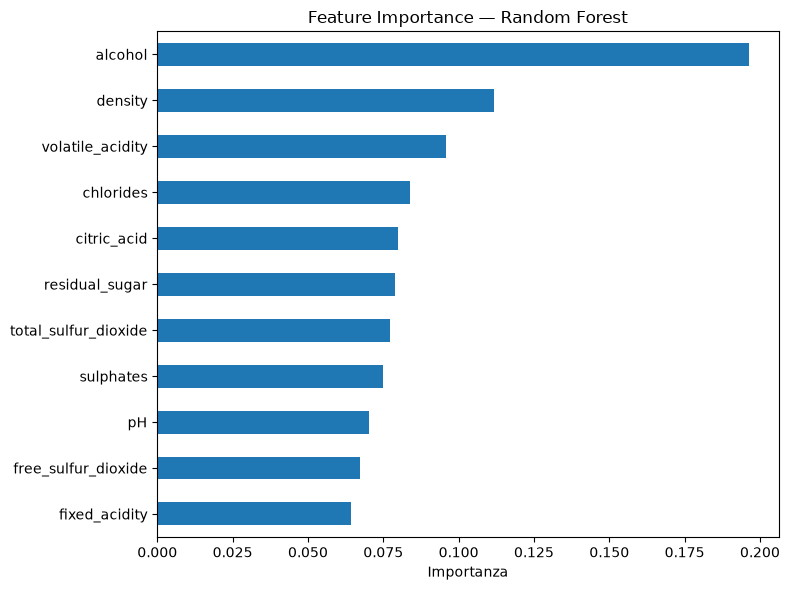

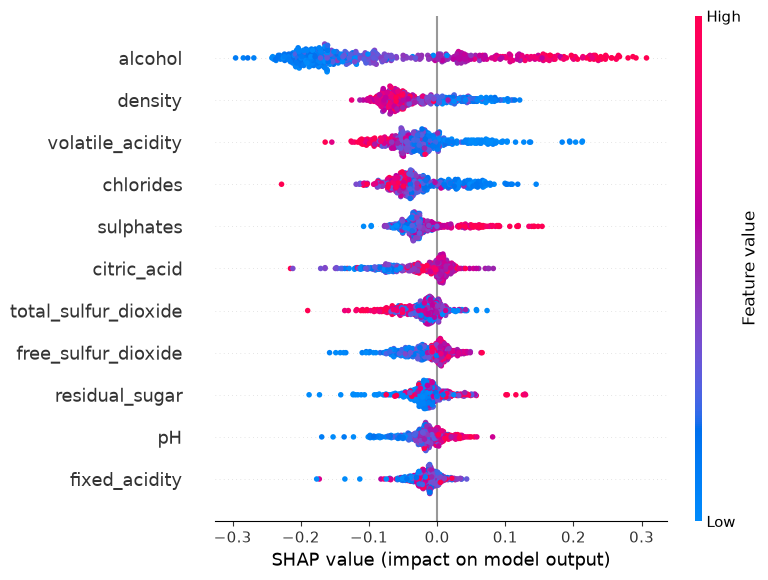

In [7]:
import matplotlib.pyplot as plt
import shap

# Random Forest classifier addestrato nella cella di confronto
rf_pipeline = pipelines["Random Forest"]
rf_model = rf_pipeline.named_steps["model"]

# Importanza globale nativa del Random Forest
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns,
).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax, title="Feature Importance — Random Forest")
ax.set_xlabel("Importanza")
fig.tight_layout()
plt.show()

# Calcola SHAP sul test set trasformato come in input al classificatore
X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
X_test_scaled = rf_pipeline.named_steps["scaler"].transform(X_test_sample)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
elif np.asarray(shap_values).ndim == 3:
    shap_values_positive = np.asarray(shap_values)[:, :, 1]
else:
    shap_values_positive = shap_values

# I valori standardizzati corrispondono agli input dati allo scaler e al modello
shap.summary_plot(
    shap_values_positive,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False,
)
plt.tight_layout()
plt.show()

## Avvio della webapp

1. Esegui la cella Python subito sotto: addestra un classificatore per riconoscere i vini di alta qualità (`quality >= 7`), lo registra su MLflow e gli assegna l'alias `production`. La webapp richiede un classificatore perché visualizza la probabilità di alta qualità; i regressori della sezione precedente stimano invece il punteggio numerico.
2. Apri un terminale nella cartella `capstone_project` (quella che contiene `app.py`) e avvia Streamlit:

   ```bash
   cd capstone_project #richiama la cartella del progetto
   uv run streamlit run app.py
   ```

3. Apri l'URL locale mostrato da Streamlit. In Codespaces, inoltra la porta `8501` dalla scheda **Ports** e visita l'URL fornito.

Per terminare la webapp, torna al terminale e premi `Ctrl+C`.

In [8]:
import os
import mlflow
from mlflow.tracking import MlflowClient

os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")
mlflow.set_tracking_uri("file:mlruns")
client = MlflowClient()

experiment = client.get_experiment_by_name("Wine Quality - Classificazione")
if experiment is None or mlflow_results_df.empty:
    raise ValueError("Esegui prima le celle di training e tracking dei classificatori.")

best_run_id = str(mlflow_results_df.iloc[0]["run_id"])
logged_models = client.search_logged_models(
    experiment_ids=[experiment.experiment_id],
    max_results=100,
)
best_logged_model = next(
    (logged_model for logged_model in logged_models if logged_model.source_run_id == best_run_id),
    None,
)
if best_logged_model is None:
    raise ValueError(f"Modello MLflow non trovato per la run migliore {best_run_id}.")

model_name = "wine_clf"
model_version = mlflow.register_model(model_uri=best_logged_model.model_uri, name=model_name)
client.set_registered_model_alias(
    name=model_name,
    alias="production",
    version=model_version.version,
)
print(f"Miglior classificatore {model_name} versione {model_version.version} impostato come production.")

Miglior classificatore wine_clf versione 6 impostato come production.


Registered model 'wine_clf' already exists. Creating a new version of this model...
Created version '6' of model 'wine_clf'.


### Nota Importante

Il codice riportato sotto deve essere eseguito **alla fine** del workflow. Questo passaggio è necessario per salvare il modello migliore in una cartella locale, che potrà essere utilizzata per il **deploy** su **Streamlit Cloud**. 

Assicurati che il modello sia stato registrato e che la versione in produzione sia stata correttamente selezionata prima di eseguire il codice.

In [9]:
import shutil
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

# Inizializza client MLflow
client = MlflowClient()
# Nome del modello registrato
model_name = "wine_clf"

model_uri = f"models:/{model_name}@production"

# Carica il modello
model = mlflow.sklearn.load_model(model_uri)

# Salva il modello in una cartella locale (model/model.pkl, letto dalla webapp come fallback)
shutil.rmtree("model", ignore_errors=True)  # sovrascrive un eventuale export precedente
mlflow.sklearn.save_model(model, "model", serialization_format="cloudpickle")


2026/10/08 14:04:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
